# Supernovae Sampling Range Validation

Test whether `sample_supernovae_for_epoch()` produces reasonable ranges for RA, Dec, and distance.
This validates that the training data sampling isn't introducing artificial bounds or invalid values.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from starccato_flow.supernovae.supernovae import Supernovae

# Load supernovae catalog
supernovae = Supernovae()
print(f"Loaded supernovae catalog with {len(supernovae.ra)} sources")
print(f"RA range: [{supernovae.ra.min():.4f}, {supernovae.ra.max():.4f}] radians")
print(f"Dec range: [{supernovae.dec.min():.4f}, {supernovae.dec.max():.4f}] radians")
print(f"Distance range: [{supernovae.distances.min():.4f}, {supernovae.distances.max():.4f}] kpc")

MPS device found
Loaded supernovae catalog with 2000000 sources
RA range: [-3.1416, 3.1416] radians
Dec range: [-1.5632, 1.5619] radians
Distance range: [0.0197, 24.8539] kpc


In [2]:
# Sample from multiple epochs to test range validity
epochs_to_test = [0, 50, 100, 200]
num_epochs = 256
samples_per_epoch = 1000

results = {}

for epoch in epochs_to_test:
    ra, dec, d = supernovae.sample_supernovae_for_epoch(
        epoch, samples_per_epoch, num_epochs, exponential=True
    )
    
    results[epoch] = {
        'ra': ra,
        'dec': dec,
        'd': d,
        'ra_min': ra.min(), 'ra_max': ra.max(), 'ra_mean': ra.mean(), 'ra_std': ra.std(),
        'dec_min': dec.min(), 'dec_max': dec.max(), 'dec_mean': dec.mean(), 'dec_std': dec.std(),
        'd_min': d.min(), 'd_max': d.max(), 'd_mean': d.mean(), 'd_std': d.std(),
    }
    
    # Check for invalid values
    has_nan_ra = np.isnan(ra).any()
    has_nan_dec = np.isnan(dec).any()
    has_nan_d = np.isnan(d).any()
    has_neg_d = (d < 0).any()
    
    print(f"\nEpoch {epoch} (exponential weighting):")
    print(f"  RA:   [{ra.min():.4f}, {ra.max():.4f}] mean={ra.mean():.4f} std={ra.std():.4f}")
    print(f"  Dec:  [{dec.min():.4f}, {dec.max():.4f}] mean={dec.mean():.4f} std={dec.std():.4f}")
    print(f"  d:    [{d.min():.4f}, {d.max():.4f}] mean={d.mean():.4f} std={d.std():.4f}")
    print(f"  Issues: NaN_RA={has_nan_ra}, NaN_Dec={has_nan_dec}, NaN_d={has_nan_d}, Neg_d={has_neg_d}")
    
    # Check bounds
    in_ra_bounds = np.logical_and(ra >= -np.pi, ra <= np.pi).sum() / len(ra) * 100
    in_dec_bounds = np.logical_and(dec >= -np.pi/2, dec <= np.pi/2).sum() / len(dec) * 100
    in_d_bounds = np.logical_and(d >= 0, d <= 1000).sum() / len(d) * 100
    
    print(f"  In bounds: RA={in_ra_bounds:.1f}%, Dec={in_dec_bounds:.1f}%, d={in_d_bounds:.1f}%")


Epoch 0 (exponential weighting):
  RA:   [-3.1336, 3.1398] mean=0.0329 std=1.8268
  Dec:  [-1.5350, 1.5252] mean=-0.0578 std=0.7056
  d:    [0.0197, 0.4999] mean=0.3803 std=0.0951
  Issues: NaN_RA=False, NaN_Dec=False, NaN_d=False, Neg_d=False
  In bounds: RA=100.0%, Dec=100.0%, d=100.0%

Epoch 50 (exponential weighting):
  RA:   [-3.1314, 3.1408] mean=0.0979 std=1.7817
  Dec:  [-1.4964, 1.3734] mean=-0.0626 std=0.7208
  d:    [0.2624, 2.4513] mean=1.8977 std=0.4627
  Issues: NaN_RA=False, NaN_Dec=False, NaN_d=False, Neg_d=False
  In bounds: RA=100.0%, Dec=100.0%, d=100.0%

Epoch 100 (exponential weighting):
  RA:   [-3.1302, 3.1337] mean=-0.1607 std=1.6538
  Dec:  [-1.2647, 1.2566] mean=-0.1044 std=0.7251
  d:    [0.6449, 4.4051] mean=3.5608 std=0.7522
  Issues: NaN_RA=False, NaN_Dec=False, NaN_d=False, Neg_d=False
  In bounds: RA=100.0%, Dec=100.0%, d=100.0%

Epoch 200 (exponential weighting):
  RA:   [-3.1329, 3.1400] mean=-0.5463 std=1.3746
  Dec:  [-1.2218, 1.1840] mean=-0.2676 s

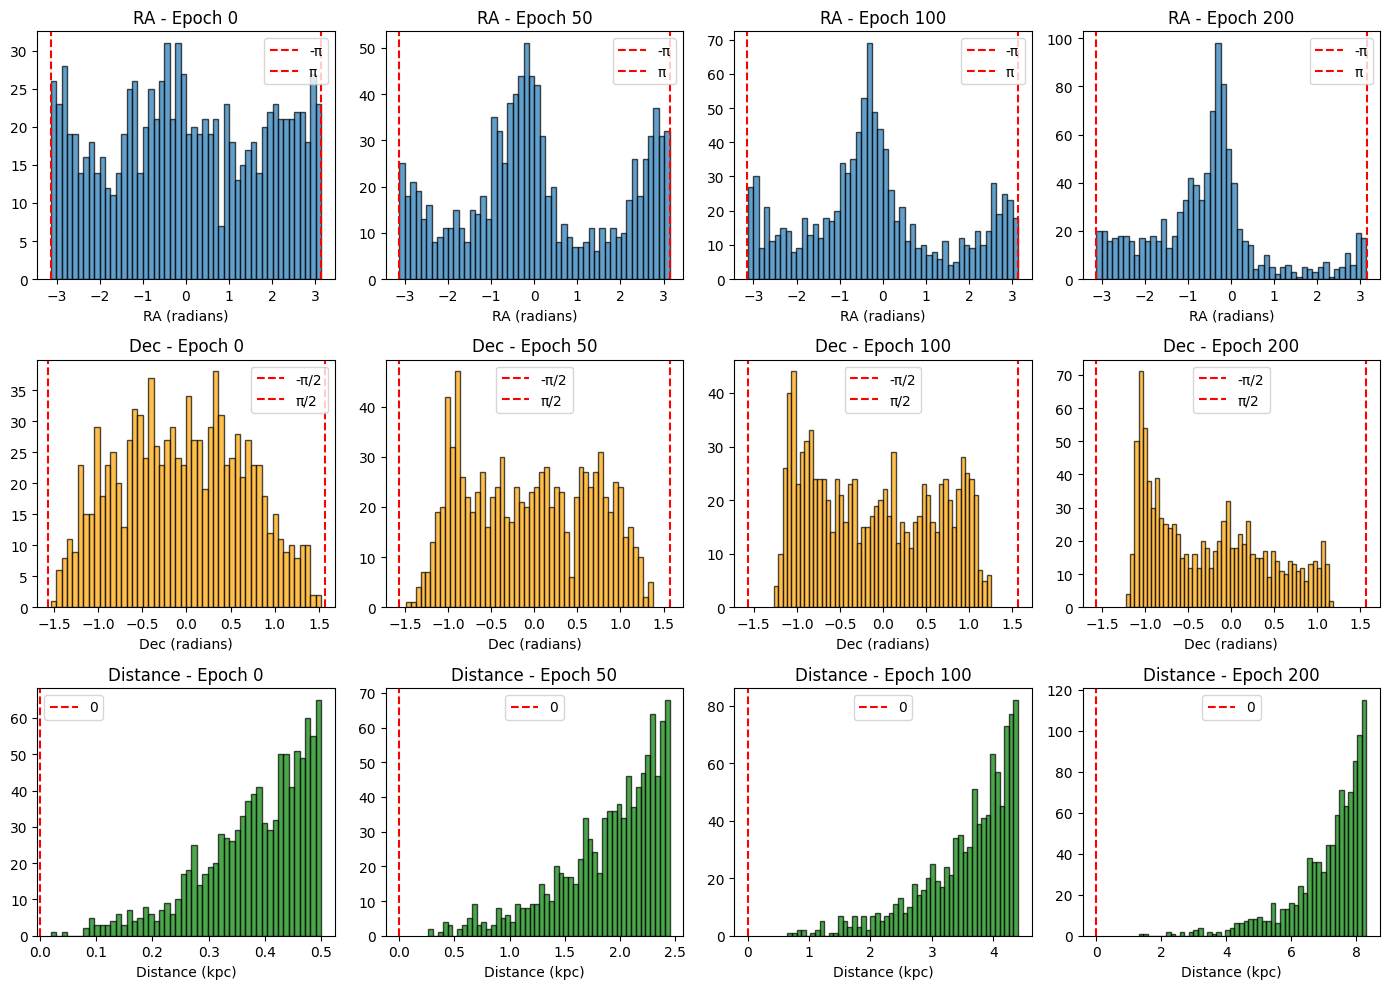


Plot saved as 'supernovae_sampling_distributions.png'


In [3]:
# Visualize distributions across epochs
fig, axes = plt.subplots(3, len(epochs_to_test), figsize=(14, 10))

for i, epoch in enumerate(epochs_to_test):
    data = results[epoch]
    
    # RA
    axes[0, i].hist(data['ra'], bins=50, alpha=0.7, edgecolor='black')
    axes[0, i].axvline(-np.pi, color='r', linestyle='--', label='-π')
    axes[0, i].axvline(np.pi, color='r', linestyle='--', label='π')
    axes[0, i].set_title(f'RA - Epoch {epoch}')
    axes[0, i].set_xlabel('RA (radians)')
    axes[0, i].legend()
    
    # Dec
    axes[1, i].hist(data['dec'], bins=50, alpha=0.7, edgecolor='black', color='orange')
    axes[1, i].axvline(-np.pi/2, color='r', linestyle='--', label='-π/2')
    axes[1, i].axvline(np.pi/2, color='r', linestyle='--', label='π/2')
    axes[1, i].set_title(f'Dec - Epoch {epoch}')
    axes[1, i].set_xlabel('Dec (radians)')
    axes[1, i].legend()
    
    # Distance
    axes[2, i].hist(data['d'], bins=50, alpha=0.7, edgecolor='black', color='green')
    axes[2, i].axvline(0, color='r', linestyle='--', label='0')
    axes[2, i].set_title(f'Distance - Epoch {epoch}')
    axes[2, i].set_xlabel('Distance (kpc)')
    axes[2, i].legend()

plt.tight_layout()
plt.savefig('supernovae_sampling_distributions.png', dpi=150)
plt.show()

print("\nPlot saved as 'supernovae_sampling_distributions.png'")

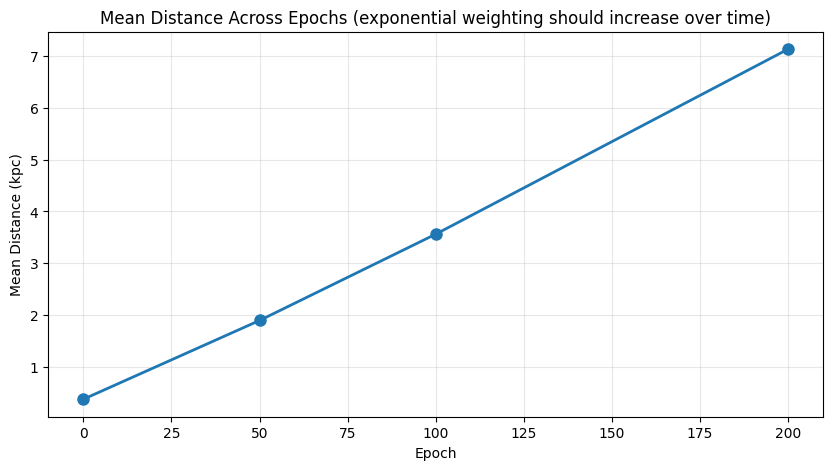


Exponential weighting validation:
  Epoch 0: mean distance = 0.3803 kpc
  Epoch 50: mean distance = 1.8977 kpc
  Epoch 100: mean distance = 3.5608 kpc
  Epoch 200: mean distance = 7.1259 kpc


In [4]:
# Verify exponential weighting pattern: early epochs should have lower mean distance
distances_by_epoch = [results[epoch]['d_mean'] for epoch in epochs_to_test]

plt.figure(figsize=(10, 5))
plt.plot(epochs_to_test, distances_by_epoch, 'o-', linewidth=2, markersize=8)
plt.xlabel('Epoch')
plt.ylabel('Mean Distance (kpc)')
plt.title('Mean Distance Across Epochs (exponential weighting should increase over time)')
plt.grid(True, alpha=0.3)
plt.savefig('mean_distance_trend.png', dpi=150)
plt.show()

print(f"\nExponential weighting validation:")
for i, epoch in enumerate(epochs_to_test):
    print(f"  Epoch {epoch}: mean distance = {distances_by_epoch[i]:.4f} kpc")

In [5]:
# Summary validation
print("=" * 60)
print("SUPERNOVAE SAMPLING VALIDATION SUMMARY")
print("=" * 60)

all_valid = True
for epoch in epochs_to_test:
    data = results[epoch]
    
    # Check for NaN
    has_issues = np.isnan(data['ra']).any() or np.isnan(data['dec']).any() or np.isnan(data['d']).any()
    
    # Check bounds
    ra_in_bounds = np.all((data['ra'] >= -np.pi) & (data['ra'] <= np.pi))
    dec_in_bounds = np.all((data['dec'] >= -np.pi/2) & (data['dec'] <= np.pi/2))
    d_positive = np.all(data['d'] >= 0)
    
    epoch_valid = ra_in_bounds and dec_in_bounds and d_positive and not has_issues
    all_valid = all_valid and epoch_valid
    
    status = "✓ VALID" if epoch_valid else "✗ INVALID"
    print(f"\nEpoch {epoch}: {status}")
    if not epoch_valid:
        if not ra_in_bounds:
            print(f"  ⚠ RA out of bounds: [{data['ra_min']:.4f}, {data['ra_max']:.4f}]")
        if not dec_in_bounds:
            print(f"  ⚠ Dec out of bounds: [{data['dec_min']:.4f}, {data['dec_max']:.4f}]")
        if not d_positive:
            print(f"  ⚠ Negative distances found: min = {data['d_min']:.4f}")
        if has_issues:
            print(f"  ⚠ NaN values detected")

print("\n" + "=" * 60)
if all_valid:
    print("✓ ALL EPOCHS VALID - Supernovae sampling ranges are good!")
else:
    print("✗ SOME EPOCHS INVALID - Check warnings above")
print("=" * 60)

SUPERNOVAE SAMPLING VALIDATION SUMMARY

Epoch 0: ✓ VALID

Epoch 50: ✓ VALID

Epoch 100: ✓ VALID

Epoch 200: ✓ VALID

✓ ALL EPOCHS VALID - Supernovae sampling ranges are good!
